
# **IMDB Movie Reviews Dataset: EDA**

The IMDB Movie Reviews Dataset is a widely used benchmark dataset for **sentiment analysis** in natural language processing. It contains a large collection of movie reviews from the Internet Movie Database (IMDb), where each review is labeled according to the sentiment expressed by the author.

The dataset contains two main columns:

| Column    | Description                             |
| --------- | --------------------------------------- |
| **text**  | The full movie review written by a user |
| **label** | The sentiment label of the review       |

The sentiment labels are encoded as:

| Label | Meaning         |
| ----- | --------------- |
| **0** | Negative review |
| **1** | Positive review |

Each row in the dataset represents one movie review and its corresponding sentiment label.



# **1: Load the dataset**

In [7]:
import pandas as pd 
import numpy as np
import matplotlib as mpl
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from datasets import load_dataset

In [6]:
#import sys
#!{sys.executable} -m pip install datasets

In [8]:
imdb = load_dataset("imdb")
df_imdb = imdb['train'].to_pandas()

df_imdb.head()

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


# **2: Exploratory Data Analysis EDA**

In [ ]:
len(df_imdb)

25000

In [ ]:
print("Total number of reviews (samples): ", len(df_imdb))

Total number of reviews (samples):  25000


In [ ]:
class_counts = df_imdb['label'].value_counts()
class_percentages = df_imdb['label'].value_counts(normalize=True) * 100

print("Class Counts:\n", class_counts)
print("\nClass Percentages:\n", class_percentages)

Class Counts:
 label
0    12500
1    12500
Name: count, dtype: int64

Class Percentages:
 label
0    50.0
1    50.0
Name: proportion, dtype: float64


In [ ]:
label_counts = df_imdb['label'].value_counts().sort_index()
labels = ['Negative', 'Positive']

colors = ["#AEC6CF", "#FFB6C1"]
sns.set_theme(style="white")

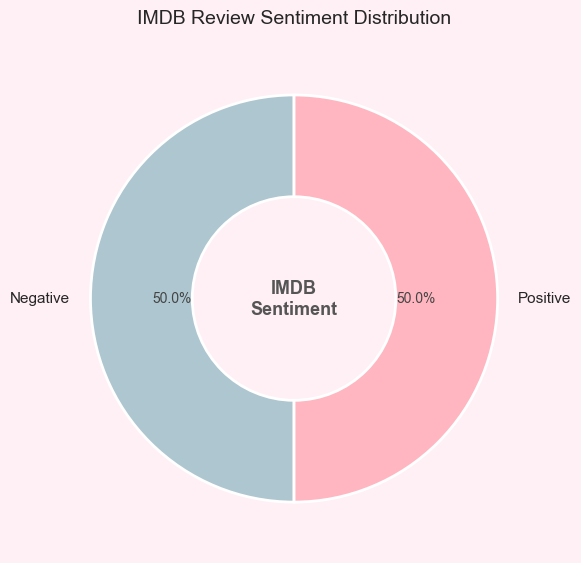

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
fig.patch.set_facecolor("#FFF0F5")
ax.set_facecolor("#FFF5F7")

wedges, texts, autotexts = ax.pie(
    label_counts,
    labels=labels,
    colors=colors,
    autopct=lambda pct: f"{pct:.1f}%",
    startangle=90,
    wedgeprops={
        'width': 0.5,
        'edgecolor': 'white',
        'linewidth': 2
    },
    textprops={'fontsize': 11}
)

for autotext in autotexts:
    autotext.set_color("#444")
    autotext.set_fontsize(10)

ax.text(0, 0, "IMDB\nSentiment", ha='center', va='center',
        fontsize=13, fontweight='bold', color="#555")
ax.set_title("IMDB Review Sentiment Distribution",
             fontsize=14, pad=15)

plt.tight_layout()
plt.show()

In [ ]:
df_eda = df_imdb.copy()
df_eda["char_length"] = df_eda["text"].apply(len)

avg_char_length = df_eda["char_length"].mean()
print("Average character length:", avg_char_length)

Average character length: 1325.06964


In [ ]:
df_eda["token_length"] = df_eda["text"].apply(lambda x: len(x.split()))

avg_token_length = df_eda["token_length"].mean()
print("Average token length:", avg_token_length)

Average token length: 233.7872


### 4. Histogram of character lengths

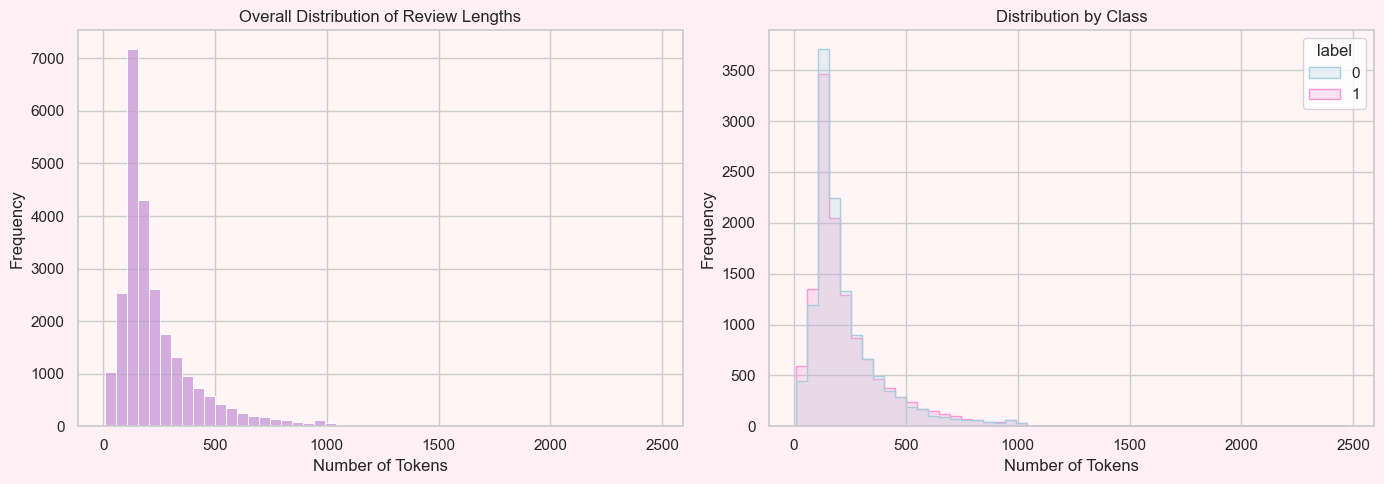

In [ ]:
sns.set_theme(style="whitegrid")
pastel_palette = ["#A6CFDD", "#FF97D7"] 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#FFF0F5") 
for ax in axes:
    ax.set_facecolor("#FFF5F7") 

sns.histplot(
    df_eda["token_length"],
    bins=50,
    color="#C694D6",  
    ax=axes[0]
)

axes[0].set_title("Overall Distribution of Review Lengths")
axes[0].set_xlabel("Number of Tokens")
axes[0].set_ylabel("Frequency")


sns.histplot(
    data=df_eda,
    x="token_length",
    hue="label",   
    bins=50,
    palette=pastel_palette,
    ax=axes[1],
    element="step",  
    stat="count",
    common_norm=False
)

axes[1].set_title("Distribution by Class")
axes[1].set_xlabel("Number of Tokens")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### 5. Display the top 20 most frequent words after basic cleaning (lowercase and remove punctuation).

In [ ]:
import nltk
from nltk.tokenize import word_tokenize
import re
from collections import Counter

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Ale\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Ale\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
def basic_clean_tokenize(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)  
    tokens = word_tokenize(text)
    return tokens

df_eda["clean_text"] = df_eda["text"].apply(basic_clean_tokenize)

In [ ]:
def word_counter_by_class(df, text_column, label_column):
    results = {}

    for label in df[label_column].unique():
        subset = df[df[label_column] == label]

        all_tokens = [] 

        for tokens in subset[text_column]:
            for word in tokens:
                all_tokens.append(word)

        results[label] = Counter(all_tokens)

    return results


In [ ]:
word_counts_by_class = word_counter_by_class(df_eda, 'clean_text', 'label')

top_words_by_class = []

for label, counter in word_counts_by_class.items():
    for word, freq in counter.most_common(20):
        top_words_by_class.append({
            "Word": word,
            "Frequency": freq,
            "class": label
        })

top_words_by_class_df = pd.DataFrame(top_words_by_class)

In [ ]:
top_words_by_class_df.head(50)

,Word,Frequency,class
0,the,162426,0
1,a,78805,0
2,and,73442,0
3,of,68740,0
4,to,68651,0
5,is,49827,0
6,in,43320,0
7,this,40451,0
8,i,40144,0
9,it,38664,0


In [ ]:
def word_counter(df, text_column):
    all_tokens = [] 
    for tokens in df[text_column]:
        for word in tokens:
            all_tokens.append(word)

    word_counts = Counter(all_tokens)

    return word_counts

In [ ]:
word_counts = word_counter(df_eda, 'clean_text')

top_20 = word_counts.most_common(20)
top_20_df = pd.DataFrame(top_20, columns=["Word", "Frequency"])
top_20_df

,Word,Frequency
0,the,334706
1,and,162227
2,a,161941
3,of,145326
4,to,135042
5,is,106852
6,in,93028
7,it,77101
8,i,75717
9,this,75190


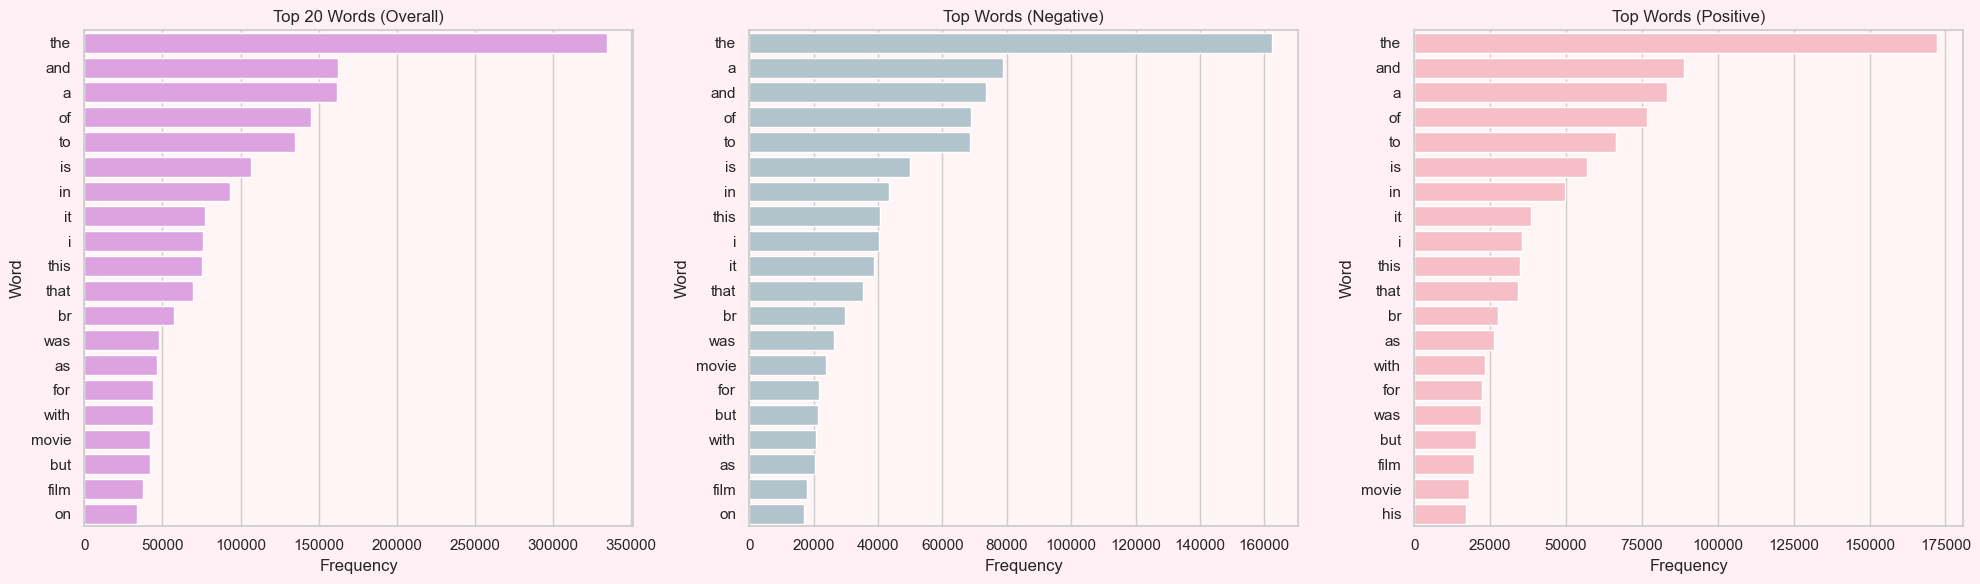

In [ ]:
sns.set_theme(style="whitegrid")

pastel_blue = "#AEC6CF"
pastel_pink = "#FFB6C1"
pastel_purple = "#E699EA"
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

fig.patch.set_facecolor("#FFF0F5")
for ax in axes:
    ax.set_facecolor("#FFF5F7")

# --- Subplot 1: Overall ---
sns.barplot(
    x="Frequency",
    y="Word",
    data=top_20_df,
    color=pastel_purple,
    ax=axes[0]
)

axes[0].set_title("Top 20 Words (Overall)")
axes[0].set_xlabel("Frequency")
axes[0].set_ylabel("Word")

# --- Subplot 2: Class 0 (Negative) ---
df_class0 = top_words_by_class_df[top_words_by_class_df["class"] == 0]

sns.barplot(
    x="Frequency",
    y="Word",
    data=df_class0,
    color=pastel_blue,
    ax=axes[1]
)

axes[1].set_title("Top Words (Negative)")
axes[1].set_xlabel("Frequency")
axes[1].set_ylabel("Word")

# --- Subplot 3: Class 1 (Positive) ---
df_class1 = top_words_by_class_df[top_words_by_class_df["class"] == 1]

sns.barplot(
    x="Frequency",
    y="Word",
    data=df_class1,
    color=pastel_pink,
    ax=axes[2]
)

axes[2].set_title("Top Words (Positive)")
axes[2].set_xlabel("Frequency")
axes[2].set_ylabel("Word")

plt.tight_layout()
plt.show()

The most frequent words are common English stopwords such as “the” and “and”, which is expected since stopword removal has not yet been applied.

# **Task 3:**  Text Preprocessing (15 points)
Implement a preprocessing function that:
1. Converts text to lowercase.
2. Removes punctuation.
3. Removes English stopwords (use NLTK).
4. Optionally applies lemmatization (WordNetLemmatizer).
Apply the function to the dataset and show examples before and after preprocessing.

In [ ]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Ale\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Ale\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Ale\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Ale\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    tokens = word_tokenize(text)
    tokens_cleaned = []
    for word in tokens:
        if word.isalpha() and word not in stop_words:
            tokens_cleaned.append(lemmatizer.lemmatize(word))
    return tokens_cleaned

In [ ]:
df_imdb["processed_text"] = df_imdb["text"].apply(preprocess)

In [ ]:
df_imdb['processed_text'].head()

0    [rented, curiousyellow, video, store, controve...
1    [curious, yellow, risible, pretentious, steami...
2    [avoid, making, type, film, future, film, inte...
3    [film, probably, inspired, godard, masculin, f...
4    [oh, brotherafter, hearing, ridiculous, film, ...
Name: processed_text, dtype: object

In [ ]:
print("Original Review:\n")
print(df_imdb["text"].iloc[0])

print("\nProcessed Review:\n")
print(df_imdb["processed_text"].iloc[0])

Original Review:

I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few an

In [ ]:
df_imdb.head()

,text,label,processed_text
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,"[rented, curiousyellow, video, store, controve..."
1,"""I Am Curious: Yellow"" is a risible and preten...",0,"[curious, yellow, risible, pretentious, steami..."
2,If only to avoid making this type of film in t...,0,"[avoid, making, type, film, future, film, inte..."
3,This film was probably inspired by Godard's Ma...,0,"[film, probably, inspired, godard, masculin, f..."
4,"Oh, brother...after hearing about this ridicul...",0,"[oh, brotherafter, hearing, ridiculous, film, ..."


In [ ]:
word_counts_cleaned = word_counter(df_imdb, 'processed_text')
top_20_cleaned = word_counts_cleaned.most_common(20)
top_20_cleaned

[('br', 57138),
 ('movie', 49596),
 ('film', 45184),
 ('one', 26667),
 ('like', 20105),
 ('time', 14869),
 ('good', 14609),
 ('character', 13806),
 ('story', 12647),
 ('even', 12504),
 ('get', 12423),
 ('would', 12135),
 ('make', 11915),
 ('see', 11762),
 ('really', 11663),
 ('scene', 10232),
 ('much', 9583),
 ('well', 9488),
 ('people', 9219),
 ('also', 9073)]

In [ ]:
top_20_cleaned

[('br', 57138),
 ('movie', 49596),
 ('film', 45184),
 ('one', 26667),
 ('like', 20105),
 ('time', 14869),
 ('good', 14609),
 ('character', 13806),
 ('story', 12647),
 ('even', 12504),
 ('get', 12423),
 ('would', 12135),
 ('make', 11915),
 ('see', 11762),
 ('really', 11663),
 ('scene', 10232),
 ('much', 9583),
 ('well', 9488),
 ('people', 9219),
 ('also', 9073)]

In [ ]:
top_20_df_cleaned = pd.DataFrame(top_20_cleaned, columns=["Word", "Frequency"])
top_20_df_cleaned.head()

,Word,Frequency
0,br,57138
1,movie,49596
2,film,45184
3,one,26667
4,like,20105


In [ ]:
word_counts_by_class_cleaned = word_counter_by_class(df_imdb, 'processed_text', 'label')

top_words_by_class_cleaned = []

for label, counter in word_counts_by_class_cleaned.items():
    for word, freq in counter.most_common(20):
        top_words_by_class_cleaned.append({
            "Word": word,
            "Frequency": freq,
            "class": label
        })

top_words_by_class_df_cleaned = pd.DataFrame(top_words_by_class_cleaned)

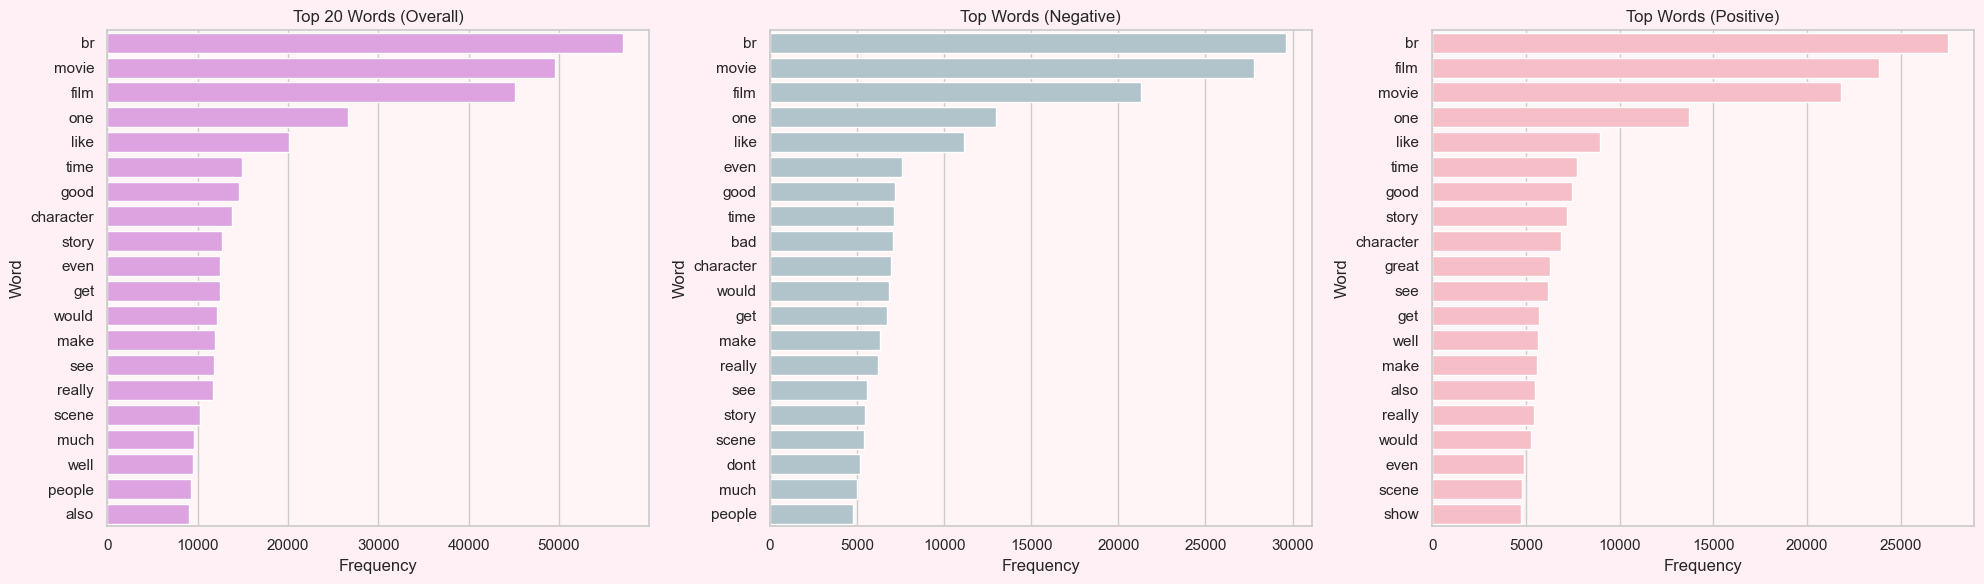

In [ ]:
sns.set_theme(style="whitegrid")

pastel_blue = "#AEC6CF"
pastel_pink = "#FFB6C1"
pastel_purple = "#E699EA"
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

fig.patch.set_facecolor("#FFF0F5")
for ax in axes:
    ax.set_facecolor("#FFF5F7")

# --- Subplot 1: Overall ---
sns.barplot(
    x="Frequency",
    y="Word",
    data=top_20_df_cleaned,
    color=pastel_purple,
    ax=axes[0]
)

axes[0].set_title("Top 20 Words (Overall)")
axes[0].set_xlabel("Frequency")
axes[0].set_ylabel("Word")

# --- Subplot 2: Class 0 (Negative) ---
df_class0 = top_words_by_class_df_cleaned[
    top_words_by_class_df_cleaned["class"] == 0
]



sns.barplot(
    x="Frequency",
    y="Word",
    data=df_class0,
    color=pastel_blue,
    ax=axes[1]
)

axes[1].set_title("Top Words (Negative)")
axes[1].set_xlabel("Frequency")
axes[1].set_ylabel("Word")

# --- Subplot 3: Class 1 (Positive) ---
df_class1 = top_words_by_class_df_cleaned[
    top_words_by_class_df_cleaned["class"] == 1
]

sns.barplot(
    x="Frequency",
    y="Word",
    data=df_class1,
    color=pastel_pink,
    ax=axes[2]
)

axes[2].set_title("Top Words (Positive)")
axes[2].set_xlabel("Frequency")
axes[2].set_ylabel("Word")

plt.tight_layout()
plt.show()

The preprocessing step removes stopwords and reduces words to their base form using lemmatization, which reduces noise and dimensionality.

# **Task 4:**  Feature Extraction (20 points)
1. Use CountVectorizer to create a Bag-of-Words representation (limit vocabulary to 10,000
features).
2. Use TfidfVectorizer to create TF-IDF features.
3. Compare the shape of both feature matrices.
4. Display example feature names.

In [ ]:
df_imdb.head()

,text,label,processed_text,processed_text_str
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,"[rented, curiousyellow, video, store, controve...",rented curiousyellow video store controversy s...
1,"""I Am Curious: Yellow"" is a risible and preten...",0,"[curious, yellow, risible, pretentious, steami...",curious yellow risible pretentious steaming pi...
2,If only to avoid making this type of film in t...,0,"[avoid, making, type, film, future, film, inte...",avoid making type film future film interesting...
3,This film was probably inspired by Godard's Ma...,0,"[film, probably, inspired, godard, masculin, f...",film probably inspired godard masculin féminin...
4,"Oh, brother...after hearing about this ridicul...",0,"[oh, brotherafter, hearing, ridiculous, film, ...",oh brotherafter hearing ridiculous film umptee...


In [ ]:
df_imdb["processed_text_str"] = df_imdb["processed_text"].apply(lambda x: " ".join(x))

## **4.1 CountVectorizer (Bag of Words)**

**CountVectorizer** is a technique used to convert text into a numerical representation by counting how many times each word appears in a document.

* Builds a **vocabulary** of all unique words in the dataset
* Represents each document as a **vector of word counts**

Sentence:

```text
"I love this movie, I love it"
```

Vocabulary:

```text
["i", "love", "this", "movie", "it"]
```

Vector representation:

```text
[2, 2, 1, 1, 1]
```

* Simple and fast
* Easy to interpret
* Works well for baseline models

However:

* Treats all words equally
* Common words (e.g., *the, is*) dominate
* Ignores word importance across documents



In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
count_vectorizer = CountVectorizer(max_features=10000)
X_count = count_vectorizer.fit_transform(df_imdb["processed_text_str"])

print("CountVectorizer shape:", X_count.shape)

CountVectorizer shape: (25000, 10000)


## **4.2 TfidVectorizer**
### **TF-IDF (Term Frequency – Inverse Document Frequency)**

**TF-IDF** improves upon CountVectorizer by weighting words based on their importance.

TF-IDF combines two concepts:

* **Term Frequency (TF):**
  How often a word appears in a document

* **Inverse Document Frequency (IDF):**
  How rare a word is across all documents


[
TF\text{-}IDF = TF \times \log\left(\frac{N}{DF}\right)
]

Where:

* (N) = total number of documents
* (DF) = number of documents containing the word



* Reduces impact of common words
* Highlights important terms
* Often improves model performance
* Slightly more complex
* Still ignores word order
* Sparse representation



In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tfidf_vectorizer = TfidfVectorizer(max_features=10000)

X_tfidf = tfidf_vectorizer.fit_transform(df_imdb["processed_text_str"])

print("TF-IDF shape:", X_tfidf.shape)

TF-IDF shape: (25000, 10000)


In [ ]:
print("CountVectorizer:", X_count.shape)
print("TF-IDF:", X_tfidf.shape)

CountVectorizer: (25000, 10000)
TF-IDF: (25000, 10000)


In [ ]:
count_features = count_vectorizer.get_feature_names_out()
tfidf_features = tfidf_vectorizer.get_feature_names_out()

print("Count features:", count_features[:20])
print("TF-IDF features:", tfidf_features[:20])

Count features: ['aaron' 'abandon' 'abandoned' 'abbot' 'abbott' 'abc' 'abducted' 'abhay'
 'ability' 'able' 'ably' 'aboard' 'abominable' 'abomination' 'aboriginal'
 'aborigine' 'abortion' 'abound' 'aboutbr' 'abr']
TF-IDF features: ['aaron' 'abandon' 'abandoned' 'abbot' 'abbott' 'abc' 'abducted' 'abhay'
 'ability' 'able' 'ably' 'aboard' 'abominable' 'abomination' 'aboriginal'
 'aborigine' 'abortion' 'abound' 'aboutbr' 'abr']


Examples of both feature extraction:

In [ ]:
nonzero_indices = X_count[0].nonzero()[1]

print("Non-zero feature indices:", nonzero_indices[:10])
print("Corresponding words:", count_features[nonzero_indices[:10]])
print("Counts:", X_count[0].toarray()[0][nonzero_indices[:10]])

Non-zero feature indices: [7348 9549 8550 1918 8757 3427 7293  275 4133 2137]
Corresponding words: ['rented' 'video' 'store' 'controversy' 'surrounded' 'first' 'released'
 'also' 'heard' 'custom']
Counts: [1 1 1 1 1 2 1 1 1 1]


In [ ]:
row = X_tfidf[0]

for idx in row.nonzero()[1][:10]:
    print(count_features[idx], "->", row[0, idx])

rented -> 0.08261074044132125
video -> 0.06086981773985581
store -> 0.07618047280349807
controversy -> 0.11100982927550151
surrounded -> 0.09648108755601602
first -> 0.07359060600416738
released -> 0.06747807646242254
also -> 0.03654199657283091
heard -> 0.06508559166149729
custom -> 0.1119291590112756


# **Task 5:**  Train a Baseline Classifier (20 points)
1. Split the dataset into training and test sets (80/20).
2. Train a Logistic Regression classifier.
3. Evaluate using accuracy, precision, recall, and F1-score.
4. Display the confusion matrix.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


### **1. Split the dataset into training and test sets (80/20).**

In [ ]:
y = df_imdb["label"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_count, y, test_size=0.2, random_state=42, stratify=y)

Xt_train, Xt_test, yt_train, yt_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

### **2. Train a Logistic Regression classifier.**

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
# CountVectorizer model
model_count = LogisticRegression(max_iter=1000)
model_count.fit(Xc_train, yc_train)



,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
# TF-IDF model
model_tfidf = LogisticRegression(max_iter=1000)
model_tfidf.fit(Xt_train, yt_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### **3. Evaluate using accuracy, precision, recall, and F1-score.**

In [ ]:
y_pred_count = model_count.predict(Xc_test)
y_pred_tfidf = model_tfidf.predict(Xt_test)

In [ ]:
def evaluate(y_true, y_pred, name):
    print(f"\n{name}")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1-score :", f1_score(y_true, y_pred))

evaluate(yc_test, y_pred_count, "CountVectorizer")
evaluate(yt_test, y_pred_tfidf, "TF-IDF")


CountVectorizer
Accuracy : 0.8704
Precision: 0.8642800944138473
Recall   : 0.8788
F1-score : 0.871479571598572

TF-IDF
Accuracy : 0.8854
Precision: 0.873015873015873
Recall   : 0.902
F1-score : 0.8872712964784576


### **4. Display the confusion matrix.**


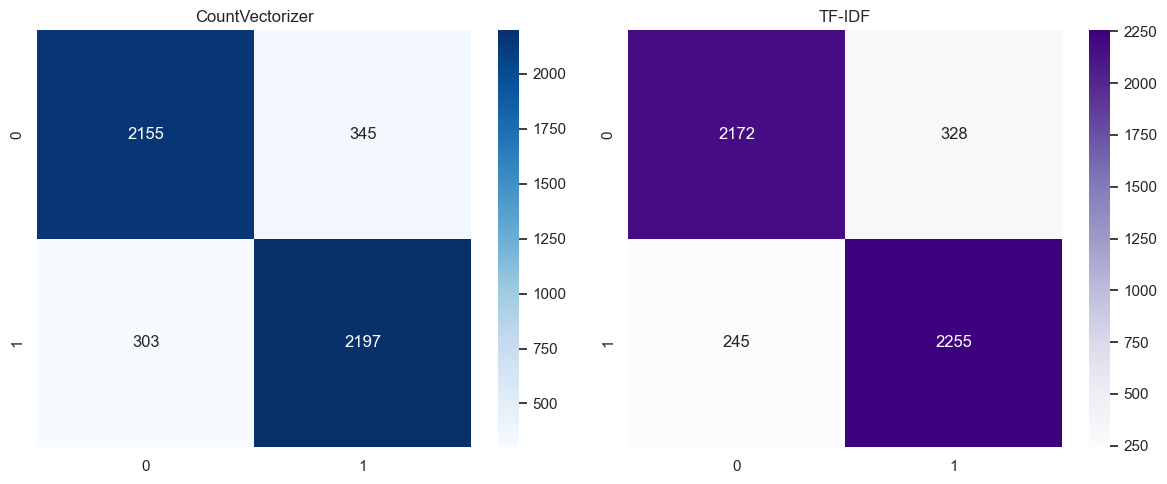

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(yc_test, y_pred_count),
            annot=True, fmt="d", ax=axes[0], cmap="Blues")
axes[0].set_title("CountVectorizer")

sns.heatmap(confusion_matrix(yt_test, y_pred_tfidf),
            annot=True, fmt="d", ax=axes[1], cmap="Purples")
axes[1].set_title("TF-IDF")

plt.tight_layout()
plt.show()

The confusion matrices show that both models perform strongly, but the TF-IDF representation provides a clear improvement over the CountVectorizer baseline. In the CountVectorizer model, 2,155 negative and 2,197 positive reviews are correctly classified, with 345 false positives and 303 false negatives. In contrast, the TF-IDF model increases correct predictions to 2,172 negatives and 2,255 positives, while reducing misclassifications to 328 false positives and 245 false negatives. This indicates that TF-IDF improves both precision and recall, particularly by reducing false negatives, meaning it is better at correctly identifying positive reviews. Overall, while both approaches are effective, TF-IDF demonstrates superior discriminative power by emphasizing informative terms and down-weighting common words, leading to more accurate and reliable sentiment classification.

### **Conceptual Questions**

**1. What is the main difference between structured and unstructured data? Why is text considered unstructured?**

Structured data is organized in a predefined format, such as tables with clearly defined rows and columns (for example, databases or spreadsheets). Each field has a specific meaning and consistent structure. Unstructured data does not follow a fixed schema and may contain irregular or complex formats. Text is considered unstructured because it consists of natural language, which does not have a strict predefined structure and can vary widely in length, grammar, vocabulary, and meaning.

---

**2. Why is preprocessing (e.g., lowercasing, stopword removal) important in NLP tasks?**

Preprocessing is important because it cleans and standardizes the text before training machine learning models. Steps such as lowercasing, removing punctuation, and eliminating stopwords reduce noise and help normalize the vocabulary. This makes the text representation more consistent and allows the model to focus on the most meaningful words that contribute to the prediction.

---

**3. What are the limitations of Bag-of-Words representations?**

Bag-of-Words has several limitations. First, it ignores the order of words, meaning that the sentence structure and context are lost. Second, it only counts word frequencies and does not capture semantic relationships between words. Finally, it often produces very high-dimensional sparse vectors, which can increase computational cost and make models harder to generalize.

---

**4. How does TF-IDF help reduce the impact of very common words?**

TF-IDF reduces the influence of very common words by assigning weights based on how important a word is within a document compared to the entire dataset. Words that appear frequently in many documents receive lower weights, while words that are more unique to a specific document receive higher weights. This helps emphasize more informative terms that are useful for distinguishing between classes.

---

**5. What does a confusion matrix tell us that accuracy alone does not?**

A confusion matrix provides detailed information about how the model performs for each class. It shows the number of correct predictions as well as false positives and false negatives. Unlike accuracy, which only gives an overall performance measure, the confusion matrix helps identify which classes are being misclassified and where the model is making mistakes.

---

**6. If your model performs poorly, list three concrete steps you would take to improve it and explain why.**

If the model performs poorly, several improvements could be considered. First, hyperparameter tuning could be applied to optimize the model parameters and improve its performance. Second, different models such as Support Vector Machines or neural networks could be tested to see if they better capture the patterns in the data. Third, more advanced text representations such as word embeddings (e.g., Word2Vec, GloVe, or BERT) could be used to capture semantic relationships between words, which may improve classification performance.